In [138]:
## import libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline

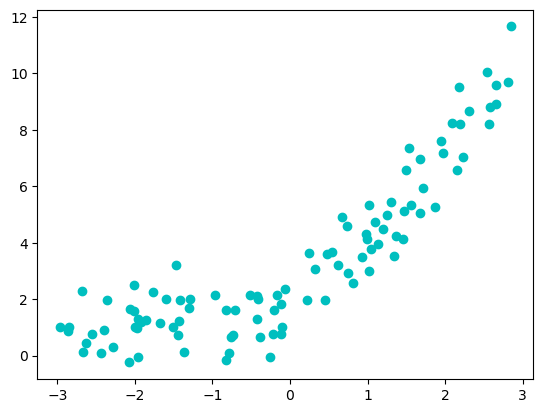

In [139]:
X = 6*np.random.rand(100,1)-3
y = 0.5*X**2 + 1.5*X + 2 + np.random.randn(100,1)
## quadratic equation used y = 0.5x^2 + 1.5x + 2 + outliers
plt.scatter(X,y,color='c')

In [140]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [141]:
## lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [142]:
regression_1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [143]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.7623888516191055


#### Lets visualize the model

Text(0, 0.5, 'Y Dataset')

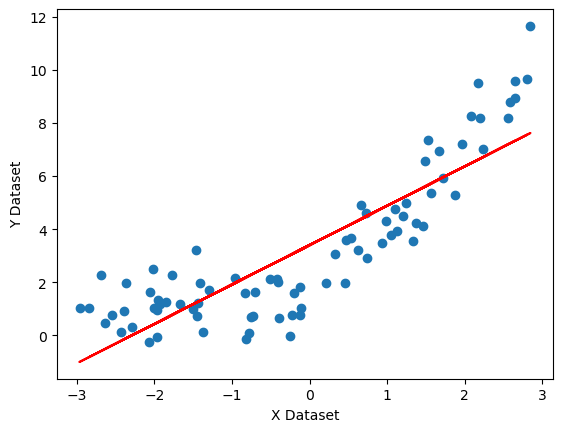

In [144]:
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')

In [145]:
## lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)

In [146]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [147]:
X_train_poly

array([[ 1.        ,  0.74438454,  0.55410834],
       [ 1.        , -1.96800389,  3.87303931],
       [ 1.        ,  0.98019681,  0.96078579],
       [ 1.        , -0.7866527 ,  0.61882247],
       [ 1.        ,  1.52785182,  2.33433118],
       [ 1.        ,  0.32611741,  0.10635257],
       [ 1.        , -2.96530172,  8.79301428],
       [ 1.        , -0.70604132,  0.49849435],
       [ 1.        ,  1.10094931,  1.21208938],
       [ 1.        , -0.96162001,  0.92471304],
       [ 1.        ,  1.0463043 ,  1.09475268],
       [ 1.        , -0.22337832,  0.04989788],
       [ 1.        , -2.68374023,  7.20246163],
       [ 1.        , -2.54836456,  6.49416192],
       [ 1.        , -2.8460228 ,  8.0998458 ],
       [ 1.        ,  2.64953502,  7.0200358 ],
       [ 1.        , -0.82609116,  0.68242661],
       [ 1.        , -2.05906068,  4.2397309 ],
       [ 1.        , -1.85592248,  3.44444827],
       [ 1.        ,  2.55918936,  6.54945017],
       [ 1.        , -0.83180265,  0.691

In [148]:
regression=LinearRegression()

In [149]:
regression.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [150]:
y_pred=regression.predict(X_test_poly)

In [151]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.7338367872318544
0.7703479877828882
0.8566427418894381


In [152]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
## display adjusted R-squared
1-(1-score)*(len(y_test))/(len(y_test) - X_test_poly.shape[1] - 1)

0.8949901167128635


0.8687376458910794

In [153]:
print(regression.coef_)
print(regression.intercept_)

[[0.         1.53628853 0.47572344]]
[2.0941813]


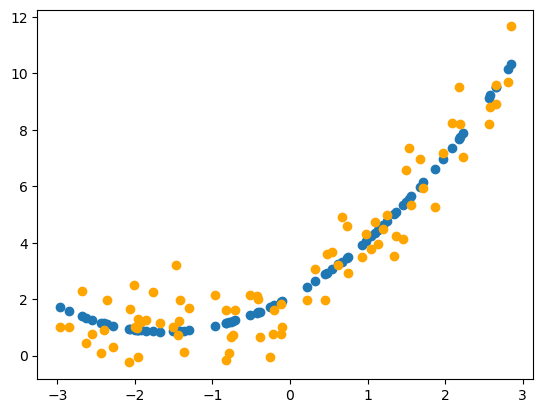

In [154]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train,color='orange')

In [155]:
## lets apply polynomial transformation Degree --> 3
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [156]:
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)

In [157]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.6608734050254701
0.7317799706429827
0.8129412063768634


In [158]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
## display adjusted R-squared
1-(1-score)*(len(y_test))/(len(y_test) - X_test_poly.shape[1] - 1)

0.905430961847691


0.8739079491302547

In [159]:
print(regression.coef_)
print(regression.intercept_)

[[0.         1.4042379  0.47635155 0.02677802]]
[2.09341778]


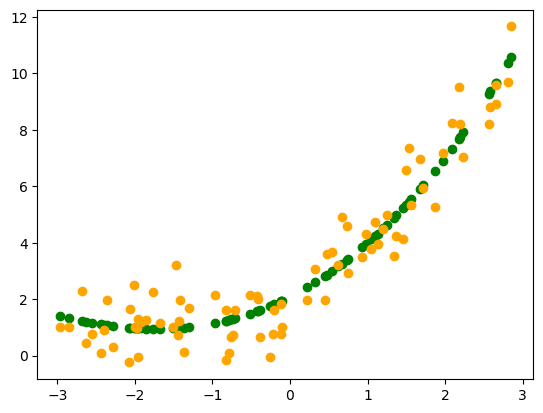

In [160]:
plt.scatter(X_train,regression.predict(X_train_poly),color='g')
plt.scatter(X_train,y_train,color='orange')

#### **Prediction of new data**

In [161]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

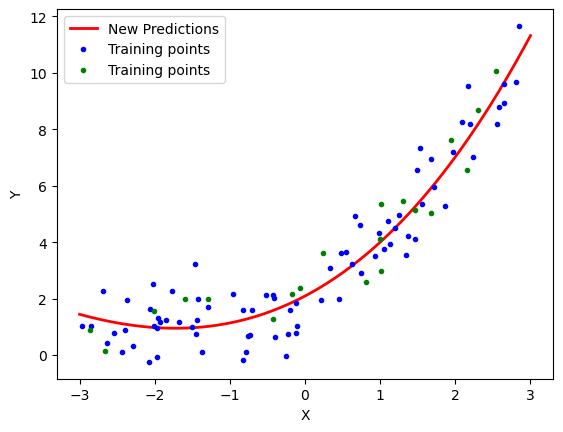

In [162]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new,y_new,'r-',linewidth=2,label="New Predictions")
plt.plot(X_train,y_train,'b.',label='Training points')
plt.plot(X_test,y_test,'g.',label='Training points')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

#### ***Pipelining Concept***

In [170]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

def poly_regression(degree):
    
    # NOTE: uses global variables -> X_train, y_train, X_test, y_test
    
    # create smooth X for curve plotting
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    # pipeline = polynomial expansion + linear regression
    model = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=True)),
        ("lin_reg", LinearRegression())
    ])
    
    # train model
    model.fit(X_train, y_train)
    
    # predict smooth curve
    y_pred_new = model.predict(X_new)
    
    # plot prediction curve
    plt.plot(X_new, y_pred_new, "r-", label=f"Degree {degree}")
    
    # plot training + test data
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    
    # formatting
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    
    plt.show()
    
    return model  # useful if you want reuse later

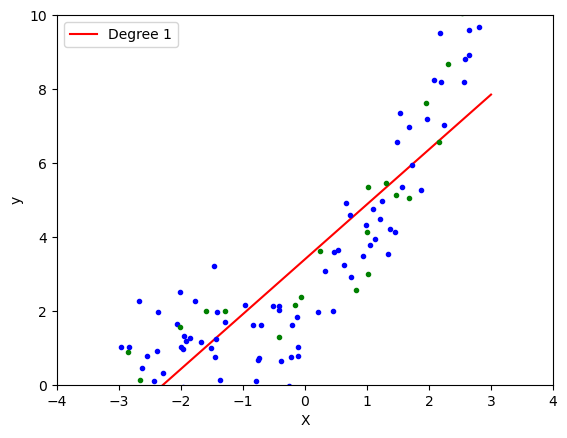

,steps,"[('poly_features', ...), ('lin_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [171]:
poly_regression(1)

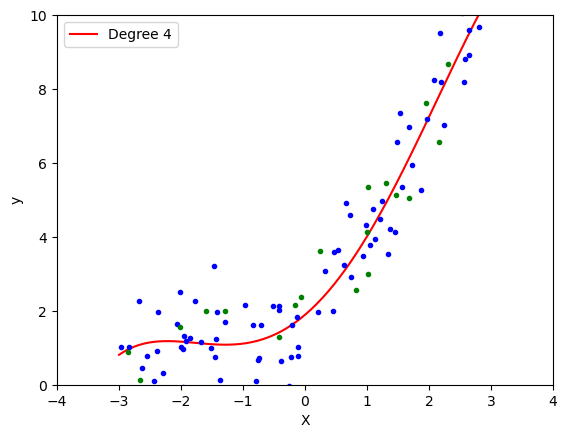

,steps,"[('poly_features', ...), ('lin_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,4
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [172]:
poly_regression(4)

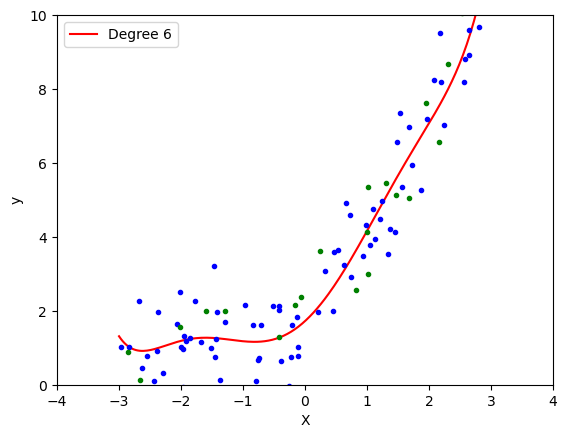

,steps,"[('poly_features', ...), ('lin_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,6
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [173]:
poly_regression(6)